In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/iris/Iris.csv
/kaggle/input/datasets/organizations/uciml/iris/database.sqlite


Dataset loaded successfully.

Dataset Overview:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


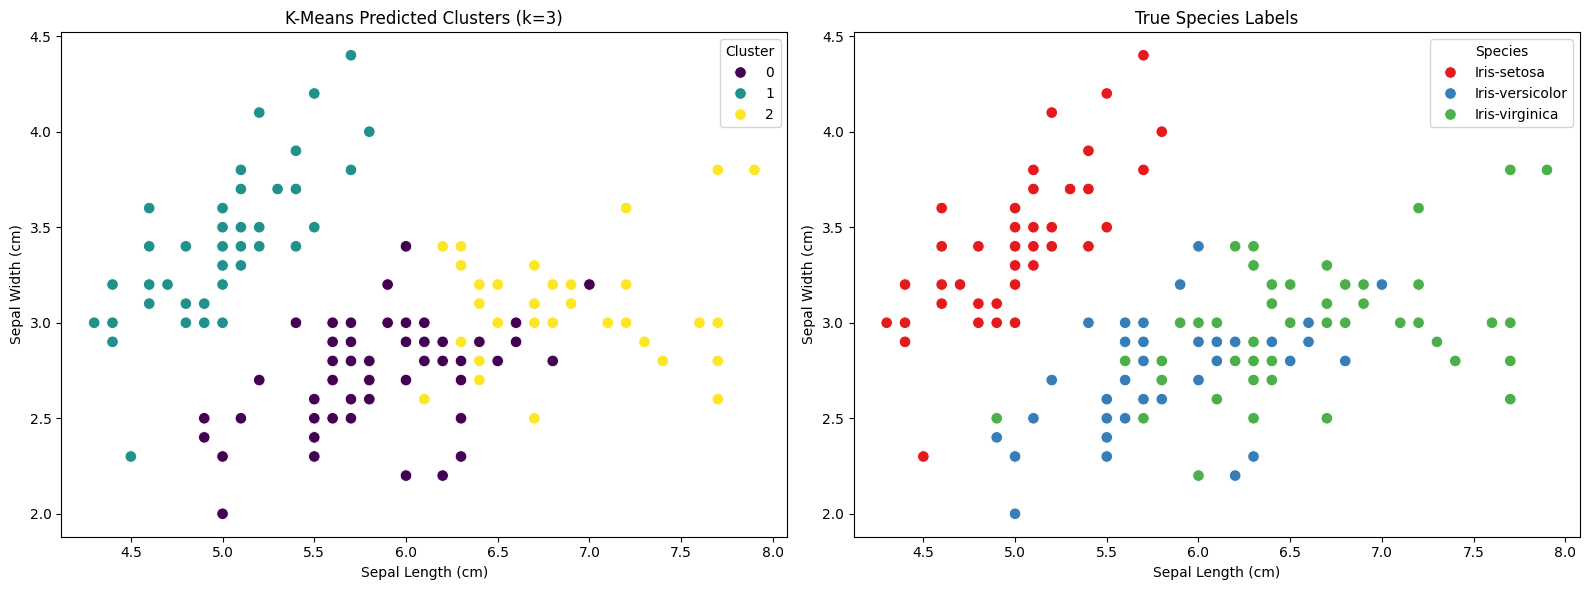


Cross-tabulation Matrix:
Species  Iris-setosa  Iris-versicolor  Iris-virginica
Cluster                                              
0                  0               48              14
1                 50                0               0
2                  0                2              36

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.77      0.96      0.86        50
 Iris-virginica       0.95      0.72      0.82        50

       accuracy                           0.89       150
      macro avg       0.91      0.89      0.89       150
   weighted avg       0.91      0.89      0.89       150



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the dataset using your environment's path
try:
    df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    df = pd.read_csv('/kaggle/input/iris/Iris.csv')
    print("Dataset loaded from backup path.")

print("\nDataset Overview:")
print(df.head())

# 2. Separate features (X) and true labels (y)
# Drop 'Id' and 'Species' so K-Means only clusters based on dimensions
X = df.drop(columns=['Id', 'Species']) if 'Id' in df.columns else df.drop(columns=['Species'])
y_true = df['Species']

# 3. Apply K-Means Clustering (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# 4. Visualize Clusters vs True Labels (Scatter Plot)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: K-Means Predicted Clusters
sns.scatterplot(
    ax=axes[0], 
    data=df, 
    x='SepalLengthCm', 
    y='SepalWidthCm', 
    hue='Cluster', 
    palette='viridis', 
    s=70
)
axes[0].set_title('K-Means Predicted Clusters (k=3)')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')

# Plot 2: True Species Labels
sns.scatterplot(
    ax=axes[1], 
    data=df, 
    x='SepalLengthCm', 
    y='SepalWidthCm', 
    hue='Species', 
    palette='Set1', 
    s=70
)
axes[1].set_title('True Species Labels')
axes[1].set_xlabel('Sepal Length (cm)')
axes[1].set_ylabel('Sepal Width (cm)')

plt.tight_layout()
plt.show()

# 5. Compare Predicted Clusters vs True Labels
print("\nCross-tabulation Matrix:")
ct = pd.crosstab(df['Cluster'], y_true)
print(ct)

# Map numeric clusters to actual species names for evaluation
cluster_mapping = ct.idxmax(axis=1).to_dict()
df['Mapped_Species'] = df['Cluster'].map(cluster_mapping)

print("\nClassification Report:")
print(classification_report(y_true, df['Mapped_Species']))